# Import

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 
# pour afficher facilement les graphiques 
from urllib.request import urlopen
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
import os
from pathlib import Path



# Fonction 

note : ajouter les entetes aux fichierx txt 
optimisation : créer une fonction d'écriture dans les fichiers 
ajouter les chemain absolues 



In [31]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().parent

BULLETINS = BASE_DIR / "BULLETINS"
DATA = BASE_DIR / "data"
OUTPUT = BASE_DIR / "output"

def export(file_name, nb_colonnes, liste_finale):
    if nb_colonnes > 1 :
        with open(file_name, "w") as f:
            for element in liste_finale :
                line = ""
                for i in range(nb_colonnes) :
                    line = line + f"{element[i]} \t" 
                line = line + " \n"
                f.writelines(line)
    if nb_colonnes == 1 :
        with open(file_name, "w") as f:
            for element in liste_finale :
                line = f"{element} \t" 
                f.writelines(line)


def frequenced_apparition(fichier):

    # construction du dictionnaire de fichier  
    dictionnaire = {}
    with open(fichier, "r") as f:
        for ligne in f:
            ligne_element = ligne.split()

            if not ligne_element:
                continue

            if ligne_element[0] in dictionnaire:
                dictionnaire[ligne_element[0]].append(ligne_element[1])
            else:
                dictionnaire[ligne_element[0]] = []
                dictionnaire[ligne_element[0]].append(ligne_element[1])
    
    # construction le la liste de liste contenant le id_document le token tftd
    liste_tftd  = []
    for dict in dictionnaire :
        for token in dictionnaire[dict] :
            tftd = dictionnaire[dict].count(token)
            liste_tftd.append([dict, token, tftd ])
    
    # suppression des doublons 
    liste_final = []
    for sous_liste in liste_tftd :
        if sous_liste not in liste_final :
            liste_final.append(sous_liste)

    # ecriture dans le fichier
    export(OUTPUT/"frequence_tftd.txt", 3, liste_final)

def coefficients_idft(fichier):
    # construciton d'un ditionnaire dont les elements au niveau 1 sont les mots .
    # au niveau 2 on a une liste de id de documents dans les quelles on trouve ses mots 
    # {'pomme': ['1'], 'chaise': ['2']}
    dictionnaire = {}
    liste_document = []
    with open(fichier, "r") as f:
        for ligne in f:
            ligne_element = ligne.split()

            if not ligne_element:
                continue

            #construction de la liste de documents 
            liste_document.append(ligne_element[0])

            if ligne_element[1] in dictionnaire and ligne_element[0] not in dictionnaire[ligne_element[1]] :
                dictionnaire[ligne_element[1]].append(ligne_element[0])
            else:
                dictionnaire[ligne_element[1]] = []
                dictionnaire[ligne_element[1]].append(ligne_element[0])
   
        print(dictionnaire)
    N  = len(list(set(liste_document)))
    # construction le la liste de liste contenant le token idft
    liste_idft  = []
    for token in dictionnaire :
        dft = len(dictionnaire[token])
        idft = np.log10(N / dft)
        liste_idft.append([ token , round(idft,4) ])

    # suppression des doublons 
    liste_final = []
    for sous_liste in liste_idft :
        if sous_liste not in liste_final :
            liste_final.append(sous_liste)
    
    # ecriture dans le fichier
    export(OUTPUT/"coeffecient_idft.txt", 2, liste_final)


def coefficients_tf_idft(file_idft, file_tftd):
    # ouverture du fichier idft
    with open(file_idft, "r") as f:
        lignes_idft = f.readlines()
        print("line_idft", lignes_idft)
    # ouverture du fichier tftd
    with open(file_tftd, "r") as f:
        lignes_tfdt = f.readlines()

    # construction de la liste contenant les trois colones : token , id-document , idft * tf
    liste_semi_finale = []
    for line_x in lignes_idft :
        for line_y in lignes_tfdt :
            if line_x.split()[0] == line_y.split()[1] :
                produit = float(line_x.split()[1]) * float(line_y.split()[2])
                id_document = line_y.split()[0]
                token = line_x.split()[0]
                liste_semi_finale.append([token, id_document, produit])

    # suppression des doublons
    liste_finale = []
    for sous_liste in liste_semi_finale :
        if sous_liste not in liste_finale:
            liste_finale.append(sous_liste)

    print(liste_finale)
    # ecriture dans le fichier 
    export(OUTPUT/"fichier_tf_idft.txt", 3, liste_finale)




def anti_dictionnaire(fichier, seuil_min , seuil_max):
    with open(fichier, 'r') as f :
        lines = f.readlines()
    
    # anti dictionnaire 
    liste_semi_finale = []
    for line in lines :
        coef = float(line.split()[3])
        token = line.split()[0]
        if  coef < seuil_min and coef > seuil_max :
            liste_semi_finale.append(token)

    # suppression de doublons 
    liste_finale = list(set(liste_semi_finale))

    # Ecriture dans le fichier 
    export(OUTPUT/"frequence_tftd.txt", 1, liste_finale)


fichier = DATA / "token.txt"
frequenced_apparition(fichier)
coefficients_idft(OUTPUT/"frequence_tftd.txt")
coefficients_tf_idft(OUTPUT/"coeffecient_idft.txt", OUTPUT/"frequence_tftd.txt" )


{'pomme': ['1'], 'chaise': ['2'], 'maison': ['2'], 'voiture': ['2'], 'soleil': ['3'], 'Ã©toile': ['3'], 'riviÃ¨re': ['4'], 'montagne': ['4'], 'forÃªt': ['4'], 'plage': ['5'], 'ocÃ©an': ['5'], 'vent': ['6'], 'pluie': ['6'], 'neige': ['7'], 'feu': ['7'], 'pierre': ['7'], 'chemin': ['8'], 'pont': ['8'], 'route': ['8'], 'ville': ['9'], 'village': ['9'], 'rue': ['9'], 'jardin': ['10'], 'arbre': ['10'], 'fleur': ['10'], 'herbe': ['11'], 'feuille': ['11'], 'racine': ['11'], 'fruit': ['12'], 'graine': ['12'], 'plante': ['12'], 'chien': ['13'], 'chat': ['13'], 'lapin': ['13'], 'renard': ['14'], 'loup': ['14'], 'ours': ['14'], 'tigre': ['15'], 'lion': ['15'], 'singe': ['15'], 'Ã©lÃ©phant': ['16'], 'cheval': ['16'], 'vache': ['16'], 'mouton': ['17'], 'poule': ['17'], 'canard': ['17'], 'poisson': ['18'], 'requin': ['18'], 'baleine': ['18'], 'oiseau': ['19'], 'aigle': ['19'], 'corbeau': ['19'], 'papillon': ['20'], 'abeille': ['20'], 'fourmi': ['20'], 'bureau': ['21'], 'Ã©cran': ['21'], 'clavier': [

# ANALYSE

In [26]:
def courbe_analytique(fichier, id_doc):
    with open(fichier, 'r') as f :
        lines = f.readlines()
    
    x = []
    y = []
    if id_doc == 0 :
        for line in lines :
            x.append(line.split()[0])
            y.append(float(line.split()[2]))
    if id_doc != 0 :
        for line in lines :
            if int(line.split()[1]) == id_doc :
                x.append(line.split()[0])
                y.append(float(line.split()[2]))
    
    plt.plot(x, y)

    plt.title("Mon graphique")
    plt.xlabel("token")
    plt.ylabel("coef")

    plt.show()

fichier = "fichier_tf_idft.txt"
courbe_analytique(fichier, 0)
    

FileNotFoundError: [Errno 2] No such file or directory: 'fichier_tf_idft.txt'

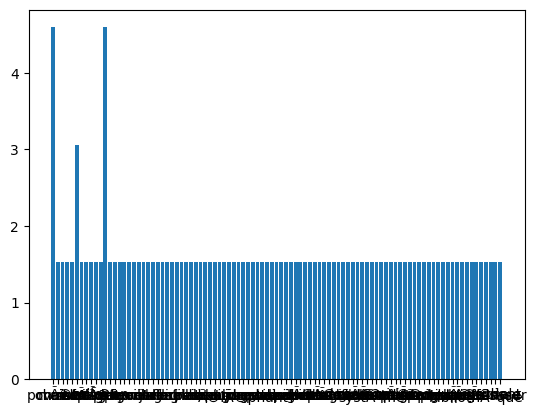

In [ ]:

frequence = {
    "pomme":3,
    "livre":1,
    "table":2
}



def courbe_analytique(fichier, id_doc):
    with open(fichier, 'r') as f :
        lines = f.readlines()
    
    frequence = {}

    if id_doc == 0 :
        for line in lines :
            frequence[line.split()[0]] = float(line.split()[2])
    if id_doc != 0 :
        for line in lines :
            if int(line.split()[1]) == id_doc :
                frequence[line.split()[0]] = float(line.split()[2])
        
    plt.bar(frequence.keys(), frequence.values())

    plt.show()

fichier = "fichier_tf_idft.txt"
courbe_analytique(fichier, 0)
    

# Test

with open("fichier.txt", "w") as f:
    f.write("Bonjour\n")
    f.write("Monde\n")